In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pandas import concat
from sklearn.metrics import mean_squared_error
from matplotlib import pyplot

In [2]:

series = pd.read_excel('D:\\7th SEM\\MTP\\GharpaUpper.xlsx',sheet_name='OnlyS11', header=0, index_col=0, squeeze=True)


In [3]:
series.head()

,Temprature,Pressure,Rain,Force,Soil Moisture,Sensor,Ax,Ay,Az,Wx,...,FileteredAz,FileteredVx,FileteredVy,FileteredVz,FileteredDx,FileteredDy,FileteredDz,CumulativeDx,CumulativeDy,CumulativeDz
DateTime,,,,,,,,,,,,,,,,,,,,,
2019-07-26 12:45:26,26,1020.36,0,0,50,s11,1.04,-0.04,0.21,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-07-26 12:55:52,26,1020.46,0,0,50,s11,1.05,-0.04,0.21,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-07-26 13:06:17,25,1020.58,0,0,50,s11,1.05,-0.05,0.22,41,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-07-26 13:16:43,25,1020.73,0,0,50,s11,1.03,-0.04,0.20,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2019-07-26 13:27:09,25,1020.73,0,0,50,s11,1.04,-0.05,0.21,-41,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df = series[['CumulativeDx','CumulativeDy','CumulativeDz']].copy()
df

,CumulativeDx,CumulativeDy,CumulativeDz
DateTime,,,
2019-07-26 12:45:26,0.000000,0.000000,0.000000
2019-07-26 12:55:52,0.000000,0.000000,0.000000
2019-07-26 13:06:17,0.000000,0.000000,0.000000
2019-07-26 13:16:43,0.000000,0.000000,0.000000
2019-07-26 13:27:09,0.000000,0.000000,0.000000
...,...,...,...
2019-10-06 00:47:24,0.001121,-0.001133,0.001097
2019-10-06 00:57:49,0.001121,-0.001133,0.001097
2019-10-06 01:08:15,0.001121,-0.001133,0.001097


In [5]:
df.isnull().sum()

CumulativeDx    0
CumulativeDy    0
CumulativeDz    0
dtype: int64

In [6]:
import math
def result(x,y,z):
    x=x*1000000
    y=y*1000000
    z=z*1000000
    res=math.sqrt(x*x+y*y+z*z)
    return res

In [7]:
df['Resultant'] = df.apply(lambda x:result(x['CumulativeDx'],x['CumulativeDy'],x['CumulativeDz']),axis=1)

In [8]:
df.tail()

,CumulativeDx,CumulativeDy,CumulativeDz,Resultant
DateTime,,,,
2019-10-06 00:47:24,0.001121,-0.001133,0.001097,1934.279787
2019-10-06 00:57:49,0.001121,-0.001133,0.001097,1934.279787
2019-10-06 01:08:15,0.001121,-0.001133,0.001097,1934.279787
2019-10-06 01:18:41,0.001121,-0.001133,0.001097,1934.279787
2019-10-06 01:29:07,0.001121,-0.001133,0.001097,1934.279787


In [9]:
df1=df[['Resultant','CumulativeDx']].copy()
df1

,Resultant,CumulativeDx
DateTime,,
2019-07-26 12:45:26,0.000000,0.000000
2019-07-26 12:55:52,0.000000,0.000000
2019-07-26 13:06:17,0.000000,0.000000
2019-07-26 13:16:43,0.000000,0.000000
2019-07-26 13:27:09,0.000000,0.000000
...,...,...
2019-10-06 00:47:24,1934.279787,0.001121
2019-10-06 00:57:49,1934.279787,0.001121
2019-10-06 01:08:15,1934.279787,0.001121


In [10]:
del df1['CumulativeDx']

In [11]:
df1

,Resultant
DateTime,
2019-07-26 12:45:26,0.000000
2019-07-26 12:55:52,0.000000
2019-07-26 13:06:17,0.000000
2019-07-26 13:16:43,0.000000
2019-07-26 13:27:09,0.000000
...,...
2019-10-06 00:47:24,1934.279787
2019-10-06 00:57:49,1934.279787
2019-10-06 01:08:15,1934.279787


In [12]:
X = df1.values
f_train_size = int(len(X)*0.66)
f_train_data,f_test_data = df1[1:f_train_size],df1[f_train_size:]

In [13]:
print(f_train_data.count())
print(f_test_data.count())
print(f_train_data.head())

Resultant    1548
dtype: int64
Resultant    799
dtype: int64
                     Resultant
DateTime                      
2019-07-26 12:55:52        0.0
2019-07-26 13:06:17        0.0
2019-07-26 13:16:43        0.0
2019-07-26 13:27:09        0.0
2019-07-26 13:37:34        0.0


### Persistence Model

In [14]:
df2 = df1[['Resultant']].copy()
df2.head()

,Resultant
DateTime,
2019-07-26 12:45:26,0.0
2019-07-26 12:55:52,0.0
2019-07-26 13:06:17,0.0
2019-07-26 13:16:43,0.0
2019-07-26 13:27:09,0.0


In [15]:
df2['t'] = df2['Resultant'].shift(1)
df2

,Resultant,t
DateTime,,
2019-07-26 12:45:26,0.000000,NaN
2019-07-26 12:55:52,0.000000,0.000000
2019-07-26 13:06:17,0.000000,0.000000
2019-07-26 13:16:43,0.000000,0.000000
2019-07-26 13:27:09,0.000000,0.000000
...,...,...
2019-10-06 00:47:24,1934.279787,1934.279787
2019-10-06 00:57:49,1934.279787,1934.279787
2019-10-06 01:08:15,1934.279787,1934.279787


In [16]:
X = df2
train_size = int(len(X) * 0.66)
train_data,test_data = df2[1:train_size],df2[train_size:]

In [17]:
print(train_data.head())
print(test_data.count())

                     Resultant    t
DateTime                           
2019-07-26 12:55:52        0.0  0.0
2019-07-26 13:06:17        0.0  0.0
2019-07-26 13:16:43        0.0  0.0
2019-07-26 13:27:09        0.0  0.0
2019-07-26 13:37:34        0.0  0.0
Resultant    799
t            799
dtype: int64


In [18]:
df1

,Resultant
DateTime,
2019-07-26 12:45:26,0.000000
2019-07-26 12:55:52,0.000000
2019-07-26 13:06:17,0.000000
2019-07-26 13:16:43,0.000000
2019-07-26 13:27:09,0.000000
...,...
2019-10-06 00:47:24,1934.279787
2019-10-06 00:57:49,1934.279787
2019-10-06 01:08:15,1934.279787


In [19]:
train_x,train_y = train_data['Resultant'],train_data['t']
test_x,test_y = test_data['Resultant'],test_data['t']

In [20]:
print(train_x)
print(train_y)

DateTime
2019-07-26 12:55:52       0.000000
2019-07-26 13:06:17       0.000000
2019-07-26 13:16:43       0.000000
2019-07-26 13:27:09       0.000000
2019-07-26 13:37:34       0.000000
                          ...     
2019-09-30 04:01:29    1520.193790
2019-09-30 04:11:55    1522.188146
2019-09-30 04:22:21    1524.187738
2019-09-30 04:32:46    1524.767768
2019-09-30 04:43:12    1525.930006
Name: Resultant, Length: 1548, dtype: float64
DateTime
2019-07-26 12:55:52       0.000000
2019-07-26 13:06:17       0.000000
2019-07-26 13:16:43       0.000000
2019-07-26 13:27:09       0.000000
2019-07-26 13:37:34       0.000000
                          ...     
2019-09-30 04:01:29    1520.193790
2019-09-30 04:11:55    1520.193790
2019-09-30 04:22:21    1522.188146
2019-09-30 04:32:46    1524.187738
2019-09-30 04:43:12    1524.767768
Name: t, Length: 1548, dtype: float64


In [21]:
predictions = test_y.copy()

In [22]:
import math
MSE = mean_squared_error(test_x,predictions)
# print('Test MSE: %.3f' % test_score)(MSE)
math.sqrt(MSE)

1.1757265032579585

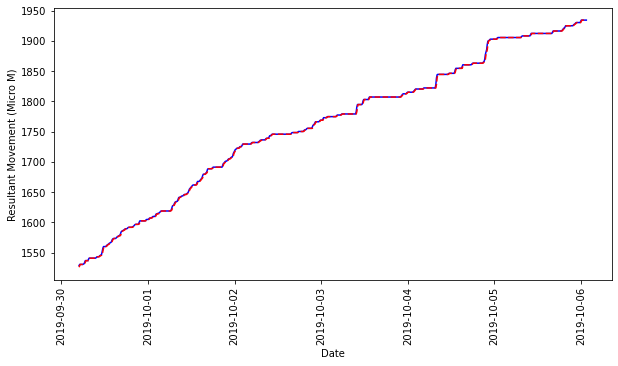

In [23]:
## for tested data
plt.figure(figsize=(10,5))
pyplot.plot(test_x,color='blue',label='Tested')
pyplot.plot(test_y,color='red',label='Predicted',linestyle='dashed')
plt.xlabel('Date')
plt.ylabel('Resultant Movement (Micro M)')
plt.xticks(rotation='vertical')
plt.show()

In [24]:
MSE = mean_squared_error(train_x,train_y)
# print('Test MSE: %.3f' % test_score)(MSE)
MSE

4.903413497240801

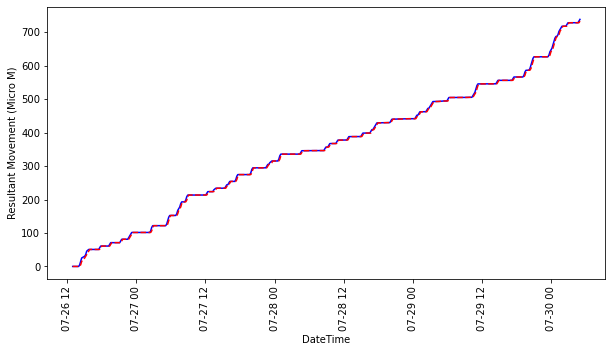

In [25]:
plt.figure(figsize=(10,5))
pyplot.plot(train_x[:500],color='blue',label='Tested')
pyplot.plot(train_y[:500],color='red',label='Predicted',linestyle='dashed')
plt.xlabel('DateTime')
plt.ylabel('Resultant Movement (Micro M)')
plt.xticks(rotation='vertical')
plt.show()


In [26]:
f_train_data['Persistence'] = train_y.copy()
f_test_data['Persistence'] = test_y.copy()

<ipython-input-26-e064ff4da462>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_train_data['Persistence'] = train_y.copy()
<ipython-input-26-e064ff4da462>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_test_data['Persistence'] = test_y.copy()


In [27]:
print(f_train_data.head())
print(f_test_data.head())

                     Resultant  Persistence
DateTime                                   
2019-07-26 12:55:52        0.0          0.0
2019-07-26 13:06:17        0.0          0.0
2019-07-26 13:16:43        0.0          0.0
2019-07-26 13:27:09        0.0          0.0
2019-07-26 13:37:34        0.0          0.0
                       Resultant  Persistence
DateTime                                     
2019-09-30 04:53:37  1528.513971  1525.930006
2019-09-30 05:04:03  1530.520924  1528.513971
2019-09-30 05:14:29  1530.520924  1530.520924
2019-09-30 05:24:54  1530.520924  1530.520924
2019-09-30 05:35:20  1530.520924  1530.520924


### Auto Regression Model

In [28]:
# create and evaluate an updated autoregressive model
from pandas import read_csv
from matplotlib import pyplot
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
from math import sqrt

In [29]:
# load dataset
# split dataset
X = df1.values
train_size1 = int(len(X)*0.66)
train_x1,test_x1 = df1[1:train_size1],df1[train_size1:]
train, test = X[:train_size1], X[train_size1:]
# ran1 = range(1878,len(test),50)
# train autoregression
window = 10
model = AutoReg(train, lags=10)
model_fit = model.fit()
coef = model_fit.params
# walk forward over time steps in test
history = train[len(train)-window:]
history = [history[i] for i in range(len(history))]
predictions = list()
for t in range(len(test)):
	length = len(history)
	lag = [history[i] for i in range(length-window,length)]
	yhat = coef[0]
	for d in range(window):
		yhat += coef[d+1] * lag[window-d-1]
	obs = test[t]
	predictions.append(yhat)
	history.append(obs)
#  	print('predicted=%f, expected=%f' % (yhat, obs))
rmse = (mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot
# pyplot.plot(test_x1,color='blue')
# pyplot.plot(predictions, color='black',linestyle='dashed')
# plt.xticks(rotation='vertical')
# plt.show()

C:\Users\imrra\anaconda3\lib\site-packages\statsmodels\tsa\ar_model.py:248: FutureWarning: The parameter names will change after 0.12 is released. Set old_names to False to use the new names now. Set old_names to True to use the old names. 
  warnings.warn(


Test RMSE: 0.443


In [30]:
temp = pd.DataFrame(predictions)
temp

,0
0,1527.017259
1,1530.700384
2,1531.305993
3,1530.183688
4,1531.242575
...,...
794,1934.053902
795,1934.673952
796,1933.998421
797,1934.699521


In [31]:
temp.index=test_x1.index

In [32]:
test_x1['Predicted'] = temp.copy()

<ipython-input-32-eb0a4248d9a1>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_x1['Predicted'] = temp.copy()


In [33]:
test_x1

,Resultant,Predicted
DateTime,,
2019-09-30 04:53:37,1528.513971,1527.017259
2019-09-30 05:04:03,1530.520924,1530.700384
2019-09-30 05:14:29,1530.520924,1531.305993
2019-09-30 05:24:54,1530.520924,1530.183688
2019-09-30 05:35:20,1530.520924,1531.242575
...,...,...
2019-10-06 00:47:24,1934.279787,1934.053902
2019-10-06 00:57:49,1934.279787,1934.673952
2019-10-06 01:08:15,1934.279787,1933.998421


#### Graph for Auto regression Test data

<AxesSubplot:xlabel='DateTime'>

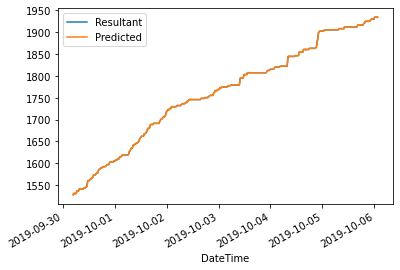

In [34]:
# pyplot.plot(color='blue')
# pyplot.plot(color='red',linestyle='dashed')
# plt.xticks(rotation='vertical')
test_x1.plot()

In [35]:
history1 = train[window:]
history1 = [history1[i] for i in range(len(history1))]
predictions1 = list()
for t in range(len(train)-(window)):
	length1 = len(history1)
	lag1 = [history1[i] for i in range(length1-(window),length1)]
	yhat1 = coef[0]
	for d in range(window):
		yhat1 += coef[d+1] * lag1[window-d-1]
	obs1 = train[t]
	predictions1.append(yhat1)
	history1.append(obs1)

In [36]:
print(len(train))
print(window)

1549
10


In [37]:
len(predictions1)

1539

In [38]:
temp1=pd.DataFrame(predictions1)

In [39]:
print(temp1.tail())
print(train_x1.tail())

                0
1534  1514.983780
1535  1515.658855
1536  1516.125297
1537  1516.814995
1538  1518.261554
                       Resultant
DateTime                        
2019-09-30 04:01:29  1520.193790
2019-09-30 04:11:55  1522.188146
2019-09-30 04:22:21  1524.187738
2019-09-30 04:32:46  1524.767768
2019-09-30 04:43:12  1525.930006


In [40]:
temp1.index = train_x1[window-1:].index

In [41]:
train_x1['Predicted'] = temp1.copy()

<ipython-input-41-3b67040129aa>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_x1['Predicted'] = temp1.copy()


In [42]:
train_x1.head(30)

,Resultant,Predicted
DateTime,,
2019-07-26 12:55:52,0.000000,NaN
2019-07-26 13:06:17,0.000000,NaN
2019-07-26 13:16:43,0.000000,NaN
2019-07-26 13:27:09,0.000000,NaN
2019-07-26 13:37:34,0.000000,NaN
2019-07-26 13:48:00,0.000000,NaN
2019-07-26 13:58:25,0.000000,NaN
2019-07-26 14:08:51,5.076675,NaN
2019-07-26 14:19:17,15.230025,NaN


In [43]:
train_x1.isnull().sum()

Resultant    0
Predicted    9
dtype: int64

In [44]:
train_x1['Predicted'].fillna(0,inplace=True)

C:\Users\imrra\anaconda3\lib\site-packages\pandas\core\series.py:4517: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().fillna(


In [45]:
train_x1

,Resultant,Predicted
DateTime,,
2019-07-26 12:55:52,0.000000,0.000000
2019-07-26 13:06:17,0.000000,0.000000
2019-07-26 13:16:43,0.000000,0.000000
2019-07-26 13:27:09,0.000000,0.000000
2019-07-26 13:37:34,0.000000,0.000000
...,...,...
2019-09-30 04:01:29,1520.193790,1514.983780
2019-09-30 04:11:55,1522.188146,1515.658855
2019-09-30 04:22:21,1524.187738,1516.125297


In [46]:
mseee = mean_squared_error(train_x1['Resultant'],train_x1['Predicted'])
print('Test RMSE: %.3f' % mseee)

Test RMSE: 8520.387


#### Graph for Auto Regression on Train Data

<AxesSubplot:xlabel='DateTime'>

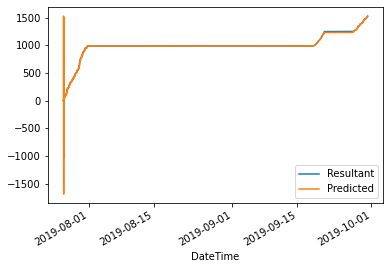

In [47]:
train_x1.plot()

In [48]:
f_train_data['Auto Regression'] = train_x1['Predicted'].copy()
f_test_data['Auto Regression'] = test_x1['Predicted'].copy()

<ipython-input-48-f6bf9a93a92a>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_train_data['Auto Regression'] = train_x1['Predicted'].copy()
<ipython-input-48-f6bf9a93a92a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  f_test_data['Auto Regression'] = test_x1['Predicted'].copy()


In [49]:
print(f_train_data.head())
print(f_test_data.head())

                     Resultant  Persistence  Auto Regression
DateTime                                                    
2019-07-26 12:55:52        0.0          0.0              0.0
2019-07-26 13:06:17        0.0          0.0              0.0
2019-07-26 13:16:43        0.0          0.0              0.0
2019-07-26 13:27:09        0.0          0.0              0.0
2019-07-26 13:37:34        0.0          0.0              0.0
                       Resultant  Persistence  Auto Regression
DateTime                                                      
2019-09-30 04:53:37  1528.513971  1525.930006      1527.017259
2019-09-30 05:04:03  1530.520924  1528.513971      1530.700384
2019-09-30 05:14:29  1530.520924  1530.520924      1531.305993
2019-09-30 05:24:54  1530.520924  1530.520924      1530.183688
2019-09-30 05:35:20  1530.520924  1530.520924      1531.242575


### ARIMA Model


In [50]:
from statsmodels.tsa.arima.model import ARIMA
from pandas import read_csv
from pandas import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt
history_arima = [x for x in train]
predictions_ar = list()
# walk-forward validation
for t in range(len(test)):
    model_arima = ARIMA(history_arima, order=(5,1,0))
    model_fit_arima = model_arima.fit()
    output = model_fit_arima.forecast()
    yhat_arima = output[0]
    predictions_ar.append(yhat_arima)
    obs_arima = test[t]
    history_arima.append(obs_arima)
    
# plot forecasts against actual outcomes


<ipython-input-50-4b326f1ba7d0>:3: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  from pandas import datetime


In [51]:
print(len(predictions_ar))
print(sqrt(mean_squared_error(test, predictions_ar)))

799
0.696573495325466


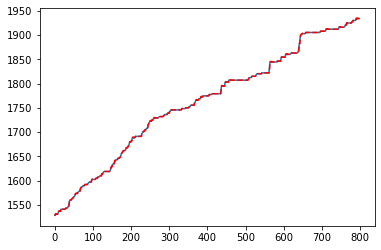

In [52]:
pyplot.plot(test)
pyplot.plot(predictions_ar, color='red',linestyle='dashed')
pyplot.show()

In [ ]:
history_arima1 = [x for x in train]
predictions_ar1 = list()
# walk-forward validation
for t in range(len(train)):
    model_arima1 = ARIMA(history_arima1, order=(5,1,0))
    model_fit_arima1 = model_arima1.fit()
    output1 = model_fit_arima1.forecast()
    yhat_arima1 = output1[0]
    predictions_ar1.append(yhat_arima1)
    obs_arima1 = train[t]
    history_arima1.append(obs_arima1)
    print('predicted=%f, expected=%f' % (yhat_arima1,obs_arima1))

In [ ]:
print(len(predictions_ar1))
print(sqrt(mean_squared_error(train[500:], predictions_ar1[500:])))

In [ ]:
pyplot.plot(train[100:150])
pyplot.plot(predictions_ar1[100:150],color='red',linestyle='dashed')

In [ ]:
temp3 = pd.DataFrame(predictions_ar)
temp4 = pd.DataFrame(predictions_ar1)

In [ ]:
print(temp3.head())
print(temp3.count())
print(temp4.head())
print(temp4.count())
print(f_train_data.count())

In [ ]:
temp3.index = f_test_data.index
temp3

In [ ]:
temp4[1:].index = f_train_data.index

In [ ]:
# plt.figure(figsize=(10,5))
# pyplot.plot(f_train_data['Resultant'][100:500],label='Actual',color='blue',linestyle='dashed')
# pyplot.plot(f_train_data['Persistence'][100:500],label='Persistence',color='black')
# pyplot.plot(f_train_data['Auto Regression'][100:500],label='Auto Regression',color='red',linestyle='dashed')
# plt.xlabel('DateTime')
# plt.ylabel('Resultant Movement (Micro M)')
# plt.xticks(rotation='vertical')
# plt.legend()
f_train_data[10:70].plot(linestyle='dashed',figsize=(10,5),title='S11 Sensor')
plt.ylabel('Movement (Micro M)')

In [ ]:
f_test_data[:70].plot(linestyle='dashed',figsize=(10,5),title='S11 Sensor')
plt.ylabel('Movement (Micro M)')